In [1]:
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np

In [3]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
plt.style.use('dark_background')

In [4]:
# Constants
G = 6.67430e-11            

## Orbit calculation functions

In [5]:
def get_period(a, M): # radius of orbit, mass
    return 2 * np.pi * np.sqrt(np.power(a, 3) / (G * M)); 

def get_angle(t, v0, P):
    return 2 * np.pi * t / P + v0

def get_pos(a, omega, i, w, M, v0, t):
    P = get_period(a, M)
    f = get_angle(t, v0, P)

    
    x = a * (np.cos(omega) * np.cos(f + w) - np.sin(omega) * np.sin(f + w) * np.cos(i))
    y = a * (np.sin(omega) * np.cos(f + w) + np.cos(omega) * np.sin(f + w) * np.cos(i))
    z = a * np.sin(f + w) * np.sin(i)

    return np.array(x), np.array(y), np.array(z)

def dxy(x1, y1, x2, y2):
    return (x1 - x2)**2 + (y1 - y2)**2

def is_transiting(a_p, M_p, omega_p, w_p, i_p, v0_p, 
               a_m, M_m, omega_m, w_m, i_m, v0_m, r_p, t):
    
    xp, yp, zp = get_pos(a_p, omega_p, i_p, w_p, M_p, v0_p, t) # planet positions
    xm, ym, zm = get_pos(a_m, omega_m, i_m, w_m, M_m, v0_m, t)  # moon positions
    
    xm += xp
    ym += yp
    zm += zp

    rp = np.stack([xp, yp, zp], axis=0) # vector from sun to planet
    rm = np.stack([xm, ym, zm], axis=0) # same but with moon
    dp = np.linalg.norm(rp, axis=0) # make length 1
    dm = np.linalg.norm(rm, axis=0)
    cos_theta = np.sum(rp * rm, axis=0) / (dp * dm) # cosine using dot product
    theta = np.arccos(cos_theta)
    alpha = np.arcsin(r_p / dp)

    sun_moon_planet = (dm < dp) & (theta <= alpha)
    sun_planet_moon = (dm >= dp) & (theta <= alpha)
    planet_moon_telescope = (zm > zp) & (dxy(xm, ym, xp, yp) <= (r_p)**2)
    moon_planet_telescope = (zm <= zp) & (dxy(xm, ym, xp, yp) <= (r_p)**2)
    # check illumination
    r_pm = rm - rp # vector from moon to planet
    d_pm = np.linalg.norm(r_pm, axis=0)
    n_sub = r_pm / d_pm  # outward surface normal
    
    # sun direction from planet
    sun_dir = -rp / dp  
    moon_spot_lit = (np.sum(n_sub * sun_dir, axis=0) > 0)

    moon_transit_on_dayside = planet_moon_telescope & moon_spot_lit

    return sun_moon_planet, sun_planet_moon, planet_moon_telescope, moon_planet_telescope, moon_transit_on_dayside, (xm, ym, zm)

## Test parameters

In [6]:
# test parameters for planet-star system
a_p = 1.0e11                  # meters, about 1 au
M_p = 2.0e30                  # kg, about the mass of the sun
omega_p = np.deg2rad(90)      # omega
w_p = np.deg2rad(45)          # phase offset
i_p = np.deg2rad(0)          # inclination
v0_p = 0.
r_p = 6.37e6   

In [12]:
# test parameters for moon-planet system
a_m = 3.84e9                  
M_m = 5.97e29                
omega_m = np.deg2rad(90)      
w_m = np.deg2rad(45)          
i_m = np.deg2rad(0)         
v0_m = 0.

In [7]:
# test parameters for planet-star system
a_p = 1.0e11                  # meters, about 1 au
M_p = 2.0e30                  # kg, about the mass of the sun
omega_p = np.deg2rad(0)      # omega
w_p = np.deg2rad(0)          # phase offset
i_p = np.deg2rad(0)          # inclination
v0_p = 0.
r_p = 6.37e6   

In [17]:
# test parameters for moon-planet system
a_m = 3.84e9              
M_m = 5.97e29               
omega_m = np.deg2rad(0)      
w_m = np.deg2rad(0)          
i_m = np.deg2rad(0)         
v0_m = 0.

In [18]:
P = get_period(a_p, M_p)
Pm = get_period(a_m, M_m)

In [19]:
def count_transits(transit_mask):
    """Count the number of distinct transit events in a boolean mask."""
    if len(transit_mask) == 0 or not transit_mask.any():
        return 0
    d = np.diff(transit_mask.astype(np.int8))
    return int(np.sum(d == 1)) + int(transit_mask[0])

## Correctness tests

In [20]:
t = r_p / (50 * (2 * np.pi * a_m / Pm))
ts = np.linspace(0, P, np.ceil(P/t).astype(np.uint64))  

In [21]:
P/t

np.float64(13750452.681737868)

In [22]:
np.ceil(P/t).astype(np.uint64)

np.uint64(13750453)

In [23]:
sun_moon_planet, sun_planet_moon, planet_moon_telescope, moon_planet_telescope, is_lit, posm = is_transiting(a_p, M_p, omega_p, w_p, i_p, v0_p, a_m, M_m, omega_m, w_m, i_m, v0_m, r_p, ts)

In [24]:
count_transits(is_lit)

0

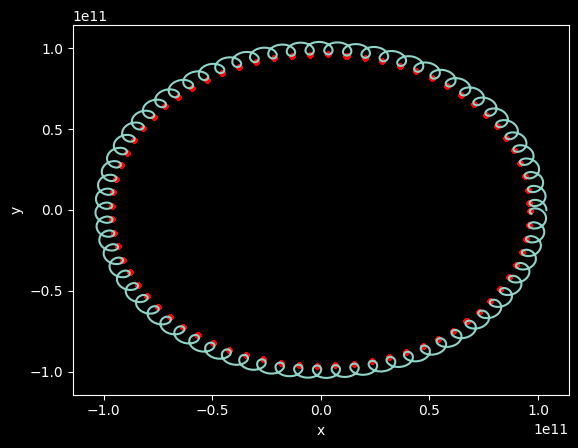

In [25]:
xm, ym, zm = posm

plt.plot(xm, ym);
plt.scatter(xm[sun_moon_planet], ym[sun_moon_planet], color="red", s=10);

plt.xlabel("x");
plt.ylabel("y");
plt.show();

In [80]:
is_lit.sum()

40001

In [ ]:
incls = np.linspace(89.9, 90.1, 1000)  
arr = []

for i in range(0, 1000):
    case1 = is_transiting(a_p, M_p, omega_p, w_p, i_p, v0_p, a_m, M_m, omega_m, w_m, np.deg2rad(incls[i]), v0_m, r_p, ts)
    arr.append(case1[0].sum())

plt.figure(figsize=(10, 6))
plt.scatter(incls, arr)
plt.xlabel(f"moon incl. theoretical limit: {np.rad2deg(np.arccos(r_p/a_m)):3g}")
plt.ylabel("ticks with transit")
plt.show()

In [ ]:
from skspatial.objects import Plane, Point

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def _plane_basis_from_normal(n):
    n = np.asarray(n, dtype=float)
    nn = np.linalg.norm(n)
    n_hat = n / nn
    a = np.array([1.0, 0.0, 0.0]) if abs(n_hat[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
    e1 = np.cross(n_hat, a)
    e1n = np.linalg.norm(e1)
    e1 /= e1n
    e2 = np.cross(n_hat, e1)
    return e1, e2, n_hat

def _project_to_plane_coords(p, e1, e2, n_hat):
    p = np.asarray(p, dtype=float)
    p_proj = p - np.dot(p, n_hat) * n_hat
    x2 = float(np.dot(p_proj, e1))
    y2 = float(np.dot(p_proj, e2))
    return x2, y2, p_proj

def draw_projected_system(
    a_p, M_p, omega_p, w_p, i_p, v0_p,
    a_m, M_m, omega_m, w_m, i_m, v0_m,
    r_p, r_m, t, pad=1.2
):

    xp, yp, zp = get_pos(a_p, omega_p, i_p, w_p, M_p, v0_p, t)
    xrel, yrel, zrel = get_pos(a_m, omega_m, i_m, w_m, M_m, v0_m, t)

    p_planet = np.array([xp, yp, zp], dtype=float)
    p_moon   = p_planet + np.array([xrel, yrel, zrel], dtype=float)

    e1, e2, n_hat = _plane_basis_from_normal(p_planet)

    mx2, my2, _ = _project_to_plane_coords(p_moon,   e1, e2, n_hat)

    fig, ax = plt.subplots(figsize=(6, 6))

    planet_disk = Circle((0, 0), r_p, alpha=0.35, color="g")
    ax.add_patch(planet_disk)

    # centers for clarity
    ax.plot([0], [0], marker="o", color="g")
    ax.plot([mx2], [my2], marker="o")

    ax.set_xlabel("plane x")
    ax.set_ylabel("plane y")
    ax.set_title(f"Projected system at t={t}")
    ax.set_aspect("equal", adjustable="box")
    ax.set_anchor("C")   

    # set limits so you can see everything
    # (use radii + separation)
    padding = 10000000
    R = np.sqrt(mx2**2 + my2**2) + padding

    ax.set_xlim(-R, R)
    ax.set_ylim(-R, R)
    
    plt.show()

In [ ]:
moon_transit_planet, moon_eclipse = is_transiting(a_p, M_p, omega_p, w_p, i_p, v0_p, a_m, M_m, omega_m, w_m, i_m, v0_m, r_p, ts)

In [ ]:
eclind = np.where(moon_eclipse)[0]
eclind

In [ ]:
draw_projected_system(
    a_p, M_p, omega_p, w_p, i_p, v0_p,
    a_m, M_m, omega_m, w_m, i_m, v0_m,
    r_p=r_p, r_m=r_p/100,  # example radii in your units
    t=ts[878922]
)


## 3d viz stuff

In [298]:
def shade_orbit_plane(ax, a, omega, i, color="white", alpha=0.1, N=200):
    theta = np.linspace(0, 2*np.pi, N)
    xc = a * np.cos(theta)
    yc = a * np.sin(theta)
    zc = np.zeros_like(theta)

    cO, sO = np.cos(omega), np.sin(omega)
    ci, si = np.cos(i), np.sin(i)

    x =  cO*xc - sO*yc*ci
    y =  sO*xc + cO*yc*ci
    z =  yc*si

    verts = [list(zip(x, y, z))]
    poly = Poly3DCollection(verts, facecolor=color, alpha=alpha, edgecolor=None)
    ax.add_collection3d(poly)


def draw_orbit(a, M, omega, w, i, v0, 
               a_m, M_m, omega_m, w_m, i_m, v0_m,
               timesteps=5000):
    P = get_period(a, M)
    ts = np.linspace(0, P, timesteps) 
    xs, ys, zs = get_pos(a, omega, i, w, M, v0, ts); # planet positions
    xm, ym, zm = get_pos(a_m, omega_m, i_m, w_m, M_m, v0_m, ts); # moon positions

    xm += xs
    ym += ys
    zm += zs

    fig = plt.figure(figsize=(12, 12))
    ax = fig.add_subplot(111, projection="3d")
    
    ax.plot(xs, ys, zs, linewidth=1, color="b", ls="--", label="planet") # planet oribt
    ax.plot(xm, ym, zm, linewidth=1, color="r", ls="-.", label="moon") # moon orbit
    
    ax.scatter([0], [0], [0], s=60, color="y")  # star
    
    # aspect ratio
    max_range = np.max([xs.max()-xs.min(), ys.max()-ys.min(), zs.max()-zs.min()])
    mx, my, mz = xs.mean(), ys.mean(), zs.mean()
    ax.set_xlim(mx - max_range/2, mx + max_range/2)
    ax.set_ylim(my - max_range/2, my + max_range/2)
    ax.set_zlim(mz - max_range/2, mz + max_range/2)

    ax.grid(False)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis.pane.set_edgecolor("white")
        
    L = max_range * 0.2
    ax.plot([-L, L], [0, 0], [0, 0], color="gray", lw=1)
    ax.plot([0, 0], [-L, L], [0, 0], color="gray", lw=1)
    ax.plot([0, 0], [0, 0], [-L, L], color="gray", lw=1)
    ax.set_xlabel("x", fontsize=16)
    ax.set_ylabel("y", fontsize=16)
    ax.set_zlabel("z", fontsize=16)
    ax.set_title("star moon planet orbit")

    shade_orbit_plane(ax, a, omega, i, alpha=.05)
    
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

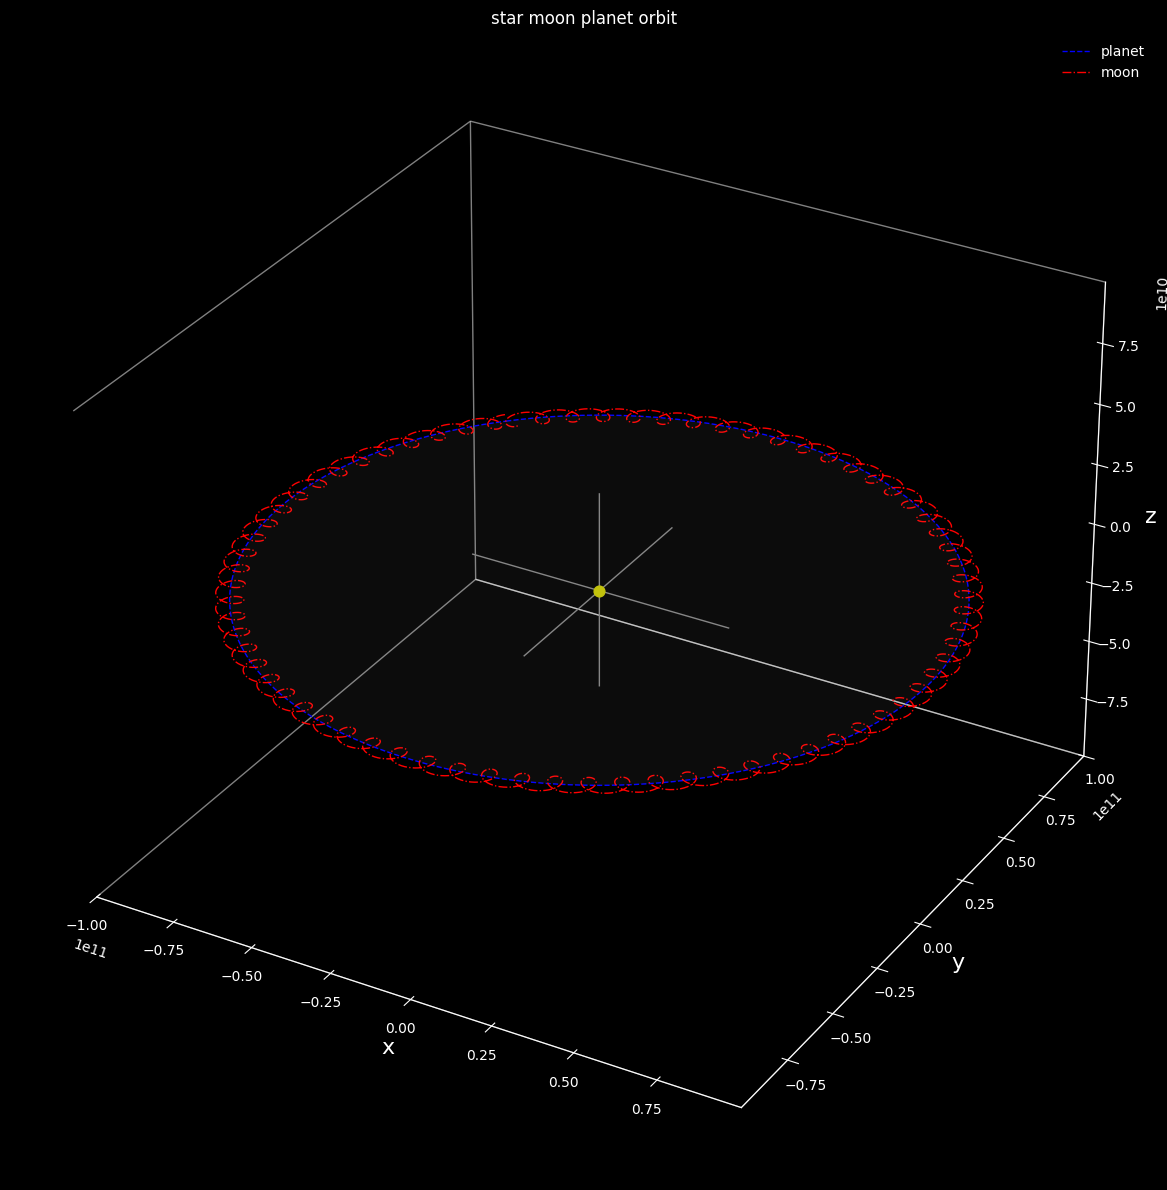

In [300]:
draw_orbit(a_p, M_p, omega_p, w_p, i_p, v0_p, 
        a_m, M_m, omega_m, w_m, i_m, v0_m);